In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [5]:
# ============================================================
# FASHION-MNIST - 4 MODEL COMPARISON PROJECT
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Conv2D,
    MaxPooling2D,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [6]:
# ============================================================
# LOAD DATASET
# ============================================================

DATA_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist"

TRAIN_PATH = os.path.join(
    DATA_PATH,
    "fashion-mnist_train.csv"
)

TEST_PATH = os.path.join(
    DATA_PATH,
    "fashion-mnist_test.csv"
)

print("Loading training data...")
train_df = pd.read_csv(TRAIN_PATH)

print("Loading testing data...")
test_df = pd.read_csv(TEST_PATH)

print("\nDataset loaded successfully!")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Loading training data...
Loading testing data...

Dataset loaded successfully!
Train shape: (60000, 785)
Test shape : (10000, 785)


In [7]:
# ============================================================
# SEPARATE FEATURES AND LABELS
# ============================================================

X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (60000, 784)
y_train: (60000,)
X_test : (10000, 784)
y_test : (10000,)


In [8]:
# ============================================================
# CLASS NAMES
# ============================================================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Number of classes:", len(class_names))

for i, name in enumerate(class_names):
    print(i, "=", name)

Number of classes: 10
0 = T-shirt/top
1 = Trouser
2 = Pullover
3 = Dress
4 = Coat
5 = Sandal
6 = Shirt
7 = Sneaker
8 = Bag
9 = Ankle boot


In [9]:
# ============================================================
# NORMALIZATION
# ============================================================

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


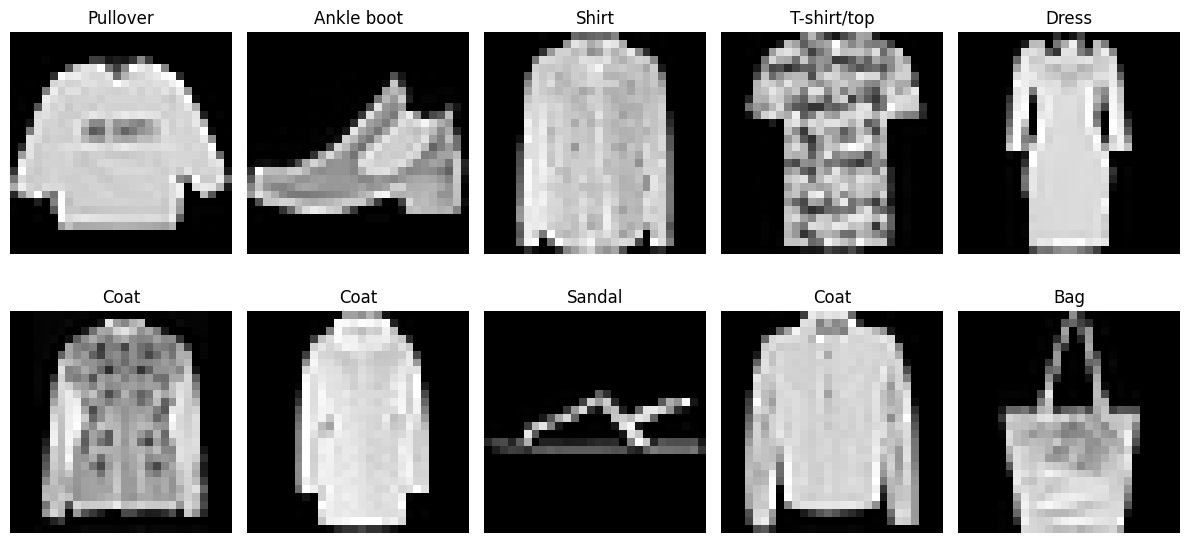

In [10]:
# ============================================================
# DISPLAY SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_train[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

CNN data

In [11]:
# ============================================================
# PREPARE CNN DATA
# ============================================================

X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print("CNN Training shape:", X_train_cnn.shape)
print("CNN Testing shape :", X_test_cnn.shape)

CNN Training shape: (60000, 28, 28, 1)
CNN Testing shape : (10000, 28, 28, 1)


In [12]:
# ============================================================
# ONE-HOT ENCODING
# ============================================================

y_train_cat = to_categorical(
    y_train,
    num_classes=10
)

y_test_cat = to_categorical(
    y_test,
    num_classes=10
)

print("Encoded training labels:", y_train_cat.shape)
print("Encoded testing labels :", y_test_cat.shape)

Encoded training labels: (60000, 10)
Encoded testing labels : (10000, 10)


In [13]:
# ============================================================
# KERAS IMPORTS
# ============================================================

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Dense,
    Flatten,
    Conv2D,
    MaxPooling2D,
    Dropout,
    BatchNormalization
)

print("Keras layers imported successfully!")

Keras layers imported successfully!


In [23]:
# ============================================================
# MODEL 1 - DENSE 7 LAYERS
# ============================================================

dense7 = Sequential([
    
    Input(shape=(784,)),
    
    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(10, activation="softmax")
])

dense7.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

dense7.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577,178 (2.20 MB)

 Trainable params: 577,178 (2.20 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ============================================================
# TRAIN MODEL 1 - DENSE 7
# ============================================================

history_dense7 = dense7.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=1
)

print("\nDense 7 training completed successfully!")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7860 - loss: 0.5983 - val_accuracy: 0.8353 - val_loss: 0.4536
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8561 - loss: 0.3976 - val_accuracy: 0.8553 - val_loss: 0.3993
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8737 - loss: 0.3484 - val_accuracy: 0.8733 - val_loss: 0.3505
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8801 - loss: 0.3241 - val_accuracy: 0.8698 - val_loss: 0.3535
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8877 - loss: 0.3032 - val_accuracy: 0.8823 - val_loss: 0.3344
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8936 - loss: 0.2885 - val_accuracy: 0.8847 - val_loss: 0.3255
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8992 - loss: 0.2735 - val_accuracy: 0.8792 - val_loss: 0.3251
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9004 - loss: 0.2639 - val_accuracy: 0.

DENSE 10 LAYERS

In [16]:
# ============================================================
# MODEL 2 - DENSE 10 LAYERS
# ============================================================

dense10 = Sequential([
    Input(shape=(784,)),

    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),

    Dense(10, activation="softmax")
])

dense10.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

dense10.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 598,906 (2.28 MB)

 Trainable params: 598,906 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ============================================================
# TRAIN MODEL 2 - DENSE 10
# ============================================================

history_dense10 = dense10.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=1
)

print("\nDense 10 training completed successfully!")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7391 - loss: 0.7250 - val_accuracy: 0.8498 - val_loss: 0.4558
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8516 - loss: 0.4167 - val_accuracy: 0.8570 - val_loss: 0.4132
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8691 - loss: 0.3641 - val_accuracy: 0.8708 - val_loss: 0.3728
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8779 - loss: 0.3368 - val_accuracy: 0.8758 - val_loss: 0.3665
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8862 - loss: 0.3163 - val_accuracy: 0.8668 - val_loss: 0.3646
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8922 - loss: 0.3000 - val_accuracy: 0.8760 - val_loss: 0.3507
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8964 - loss: 0.2831 - val_accuracy: 0.8848 - val_loss: 0.3324
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8976 - loss: 0.2793 - val_accuracy: 0.

CNN 3 LAYERS MODEL 

In [18]:
# ============================================================
# MODEL 3 - CNN 3 CONVOLUTIONAL LAYERS
# ============================================================

cnn3 = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

cnn3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================================
# TRAIN MODEL 3 - CNN 3
# ============================================================

history_cnn3 = cnn3.fit(
    X_train_cnn,
    y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=1
)

print("\nCNN 3 training completed successfully!")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.7773 - loss: 0.6121 - val_accuracy: 0.8663 - val_loss: 0.3736
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.8692 - loss: 0.3614 - val_accuracy: 0.8920 - val_loss: 0.3034
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.8880 - loss: 0.3075 - val_accuracy: 0.8888 - val_loss: 0.3012
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.9018 - loss: 0.2736 - val_accuracy: 0.9068 - val_loss: 0.2562
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.9080 - loss: 0.2513 - val_accuracy: 0.9073 - val_loss: 0.2457
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.9154 - loss: 0.2301 - val_accuracy: 0.9172 - val_loss: 0.2321
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9211 - loss: 0.2130 - val_accuracy: 0.9045 - val_loss: 0.2478
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.9291 - loss: 0.1958 - 

In [24]:
# ============================================================
# MODEL 4 - CNN 5 CONVOLUTIONAL LAYERS
# ============================================================

cnn5 = Sequential([
    Input(shape=(28, 28, 1)),

    # Block 1
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Block 2
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Block 3
    Conv2D(128, (3, 3), activation="relu", padding="same"),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.4),

    Dense(10, activation="softmax")
])

cnn5.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn5.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 943,466 (3.60 MB)

 Trainable params: 943,274 (3.60 MB)

 Non-trainable params: 192 (768.00 B)

In [25]:
# ============================================================
# TRAIN MODEL 4 - CNN 5
# ============================================================

history_cnn5 = cnn5.fit(
    X_train_cnn,
    y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=1
)

print("\nCNN 5 training completed successfully!")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 190ms/step - accuracy: 0.8009 - loss: 0.5574 - val_accuracy: 0.7338 - val_loss: 0.7424
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 190ms/step - accuracy: 0.8799 - loss: 0.3395 - val_accuracy: 0.8958 - val_loss: 0.2798
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 190ms/step - accuracy: 0.8933 - loss: 0.2944 - val_accuracy: 0.9075 - val_loss: 0.2661
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 192ms/step - accuracy: 0.9064 - loss: 0.2618 - val_accuracy: 0.9173 - val_loss: 0.2330
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 190ms/step - accuracy: 0.9098 - loss: 0.2452 - val_accuracy: 0.9117 - val_loss: 0.2484
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 190ms/step - accuracy: 0.9167 - loss: 0.2301 - val_accuracy: 0.9163 - val_loss: 0.2254
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 190ms/step - accuracy: 0.9219 - loss: 0.2153 - val_accuracy: 0.9083 - val_loss: 0.2672
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 189ms/step - accuracy: 0.9244 - loss: 0

In [26]:
# ============================================================
# EVALUATE ALL 4 MODELS ON TEST DATA
# ============================================================

loss7, acc7 = dense7.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

loss10, acc10 = dense10.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

losscnn3, acccnn3 = cnn3.evaluate(
    X_test_cnn,
    y_test_cat,
    verbose=0
)

losscnn5, acccnn5 = cnn5.evaluate(
    X_test_cnn,
    y_test_cat,
    verbose=0
)

print("============================================")
print("       MODEL TEST RESULTS")
print("============================================")
print(f"Dense 7  Test Accuracy : {acc7:.4f}")
print(f"Dense 10 Test Accuracy : {acc10:.4f}")
print(f"CNN 3    Test Accuracy : {acccnn3:.4f}")
print(f"CNN 5    Test Accuracy : {acccnn5:.4f}")
print("============================================")

       MODEL TEST RESULTS
Dense 7  Test Accuracy : 0.0354
Dense 10 Test Accuracy : 0.8885
CNN 3    Test Accuracy : 0.9219
CNN 5    Test Accuracy : 0.9371


In [27]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Dense 7 Layers",
        "Dense 10 Layers",
        "CNN 3 Layers",
        "CNN 5 Layers"
    ],
    "Test Loss": [
        loss7,
        loss10,
        losscnn3,
        losscnn5
    ],
    "Test Accuracy": [
        acc7,
        acc10,
        acccnn3,
        acccnn5
    ]
})

# Accuracy percentage
results["Accuracy (%)"] = results["Test Accuracy"] * 100

# Sort from best to worst
results = results.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

display(results)

print("\n🏆 BEST MODEL:")
print(results.iloc[0]["Model"])
print(f"Accuracy: {results.iloc[0]['Accuracy (%)']:.2f}%")

,Model,Test Loss,Test Accuracy,Accuracy (%)
0,CNN 5 Layers,0.176634,0.9371,93.709999
1,CNN 3 Layers,0.228154,0.9219,92.189997
2,Dense 10 Layers,0.319232,0.8885,88.849998
3,Dense 7 Layers,2.319001,0.0354,3.540000



🏆 BEST MODEL:
CNN 5 Layers
Accuracy: 93.71%


In [28]:
# ============================================================
# PRECISION, RECALL & F1-SCORE FOR ALL 4 MODELS
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
pred_dense7 = np.argmax(dense7.predict(X_test, verbose=0), axis=1)
pred_dense10 = np.argmax(dense10.predict(X_test, verbose=0), axis=1)
pred_cnn3 = np.argmax(cnn3.predict(X_test_cnn, verbose=0), axis=1)
pred_cnn5 = np.argmax(cnn5.predict(X_test_cnn, verbose=0), axis=1)

# Calculate metrics
metrics_results = pd.DataFrame({
    "Model": [
        "Dense 7 Layers",
        "Dense 10 Layers",
        "CNN 3 Layers",
        "CNN 5 Layers"
    ],
    "Accuracy (%)": [
        accuracy_score(y_test, pred_dense7) * 100,
        accuracy_score(y_test, pred_dense10) * 100,
        accuracy_score(y_test, pred_cnn3) * 100,
        accuracy_score(y_test, pred_cnn5) * 100
    ],
    "Precision (%)": [
        precision_score(y_test, pred_dense7, average="weighted") * 100,
        precision_score(y_test, pred_dense10, average="weighted") * 100,
        precision_score(y_test, pred_cnn3, average="weighted") * 100,
        precision_score(y_test, pred_cnn5, average="weighted") * 100
    ],
    "Recall (%)": [
        recall_score(y_test, pred_dense7, average="weighted") * 100,
        recall_score(y_test, pred_dense10, average="weighted") * 100,
        recall_score(y_test, pred_cnn3, average="weighted") * 100,
        recall_score(y_test, pred_cnn5, average="weighted") * 100
    ],
    "F1-Score (%)": [
        f1_score(y_test, pred_dense7, average="weighted") * 100,
        f1_score(y_test, pred_dense10, average="weighted") * 100,
        f1_score(y_test, pred_cnn3, average="weighted") * 100,
        f1_score(y_test, pred_cnn5, average="weighted") * 100
    ]
})

metrics_results = metrics_results.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

display(metrics_results)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,CNN 5 Layers,93.71,93.677278,93.71,93.670818
1,CNN 3 Layers,92.19,92.508834,92.19,92.236549
2,Dense 10 Layers,88.85,89.381419,88.85,88.986136
3,Dense 7 Layers,3.54,6.322090,3.54,2.201493


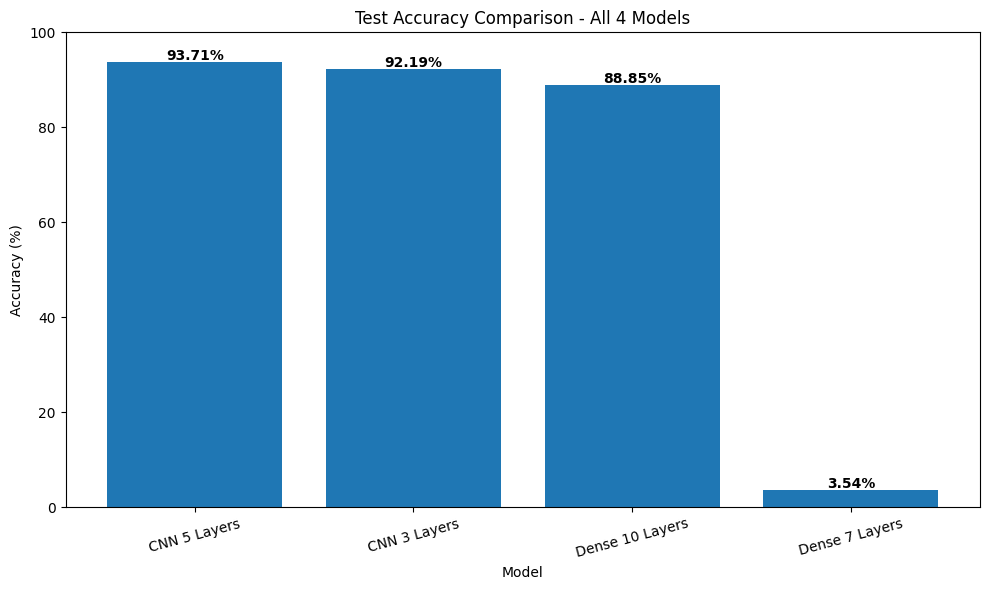

In [30]:
# ============================================================
# ACCURACY COMPARISON GRAPH
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    metrics_results["Model"],
    metrics_results["Accuracy (%)"]
)

plt.title("Test Accuracy Comparison - All 4 Models")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, value in enumerate(metrics_results["Accuracy (%)"]):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

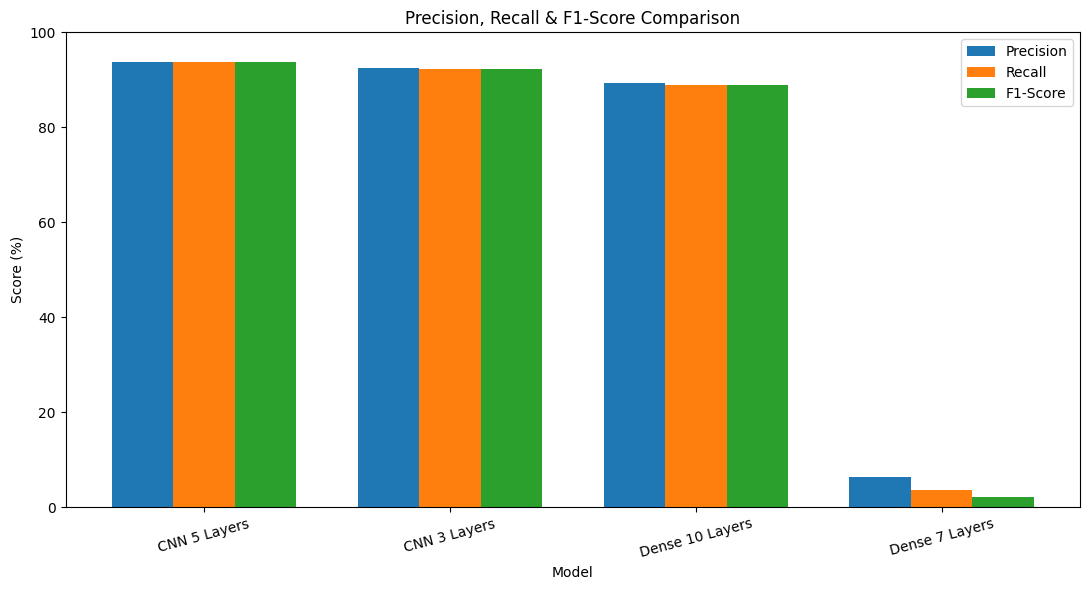

In [31]:
# ============================================================
# PRECISION, RECALL & F1-SCORE COMPARISON
# ============================================================

plt.figure(figsize=(11, 6))

x = np.arange(len(metrics_results["Model"]))
width = 0.25

plt.bar(
    x - width,
    metrics_results["Precision (%)"],
    width,
    label="Precision"
)

plt.bar(
    x,
    metrics_results["Recall (%)"],
    width,
    label="Recall"
)

plt.bar(
    x + width,
    metrics_results["F1-Score (%)"],
    width,
    label="F1-Score"
)

plt.title("Precision, Recall & F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)

plt.xticks(
    x,
    metrics_results["Model"],
    rotation=15
)

plt.legend()
plt.tight_layout()
plt.show()

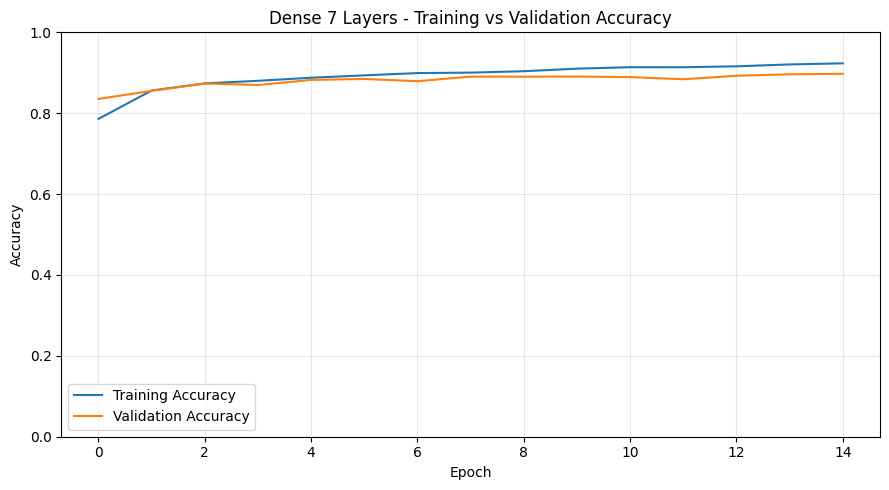

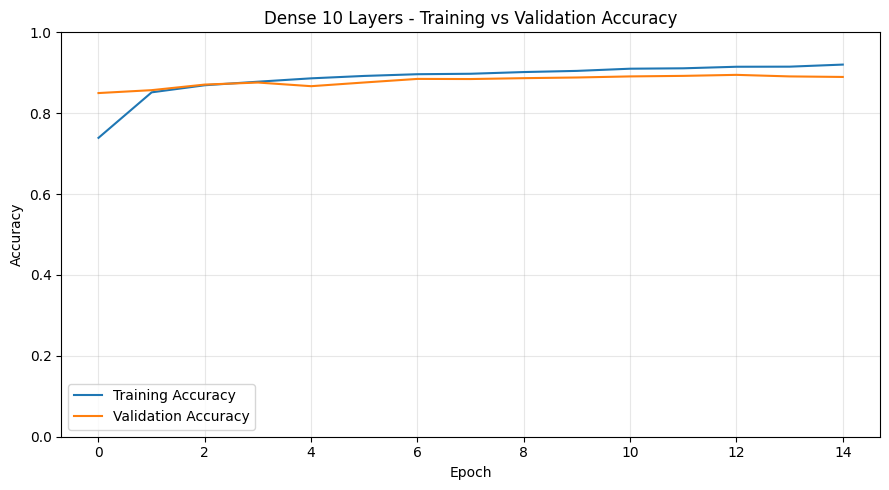

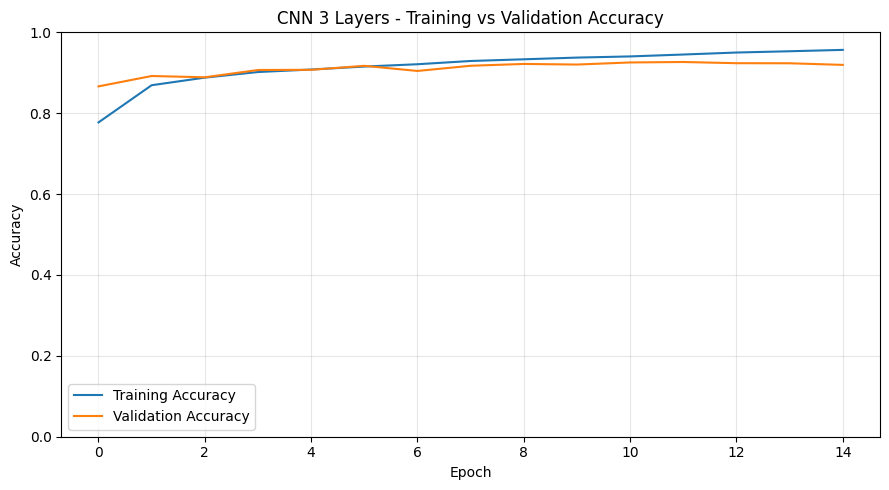

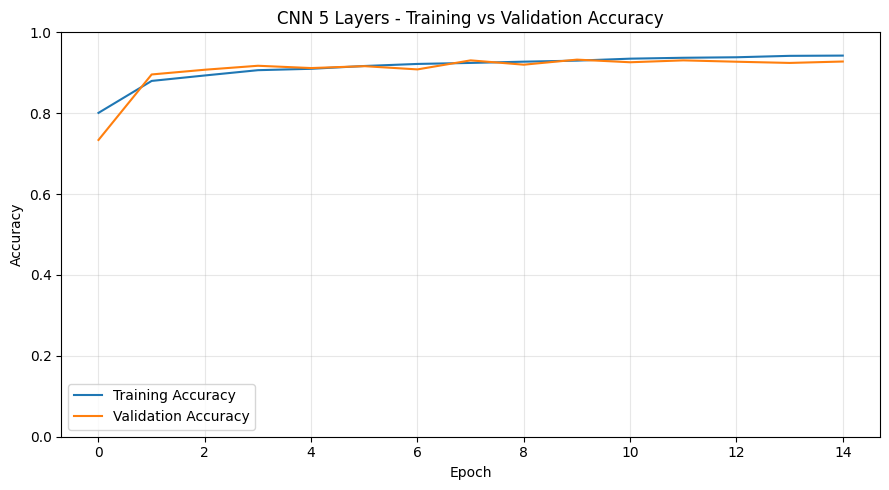

In [32]:
# ============================================================
# TRAINING vs VALIDATION ACCURACY - ALL 4 MODELS
# ============================================================

histories = {
    "Dense 7 Layers": history_dense7,
    "Dense 10 Layers": history_dense10,
    "CNN 3 Layers": history_cnn3,
    "CNN 5 Layers": history_cnn5
}

for model_name, history in histories.items():

    plt.figure(figsize=(9, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(f"{model_name} - Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

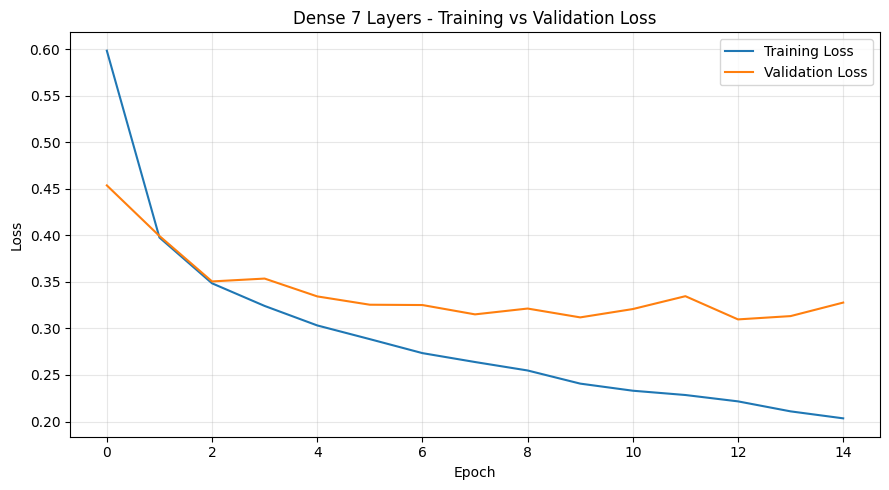

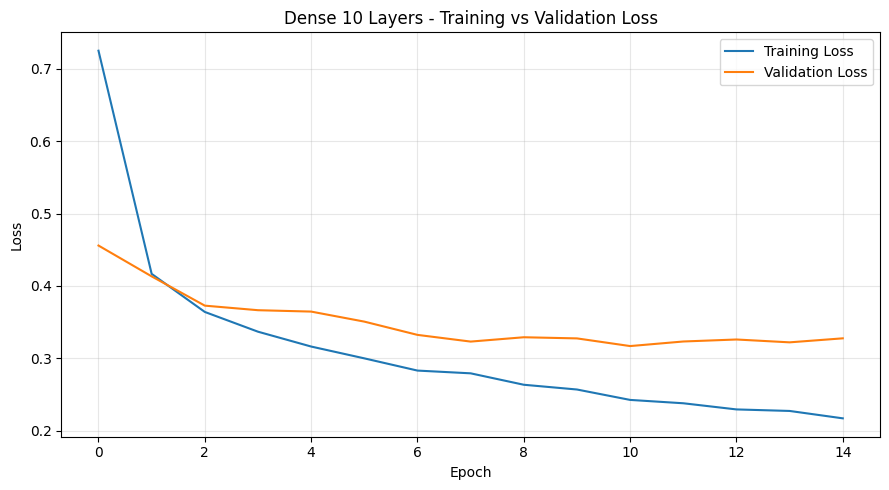

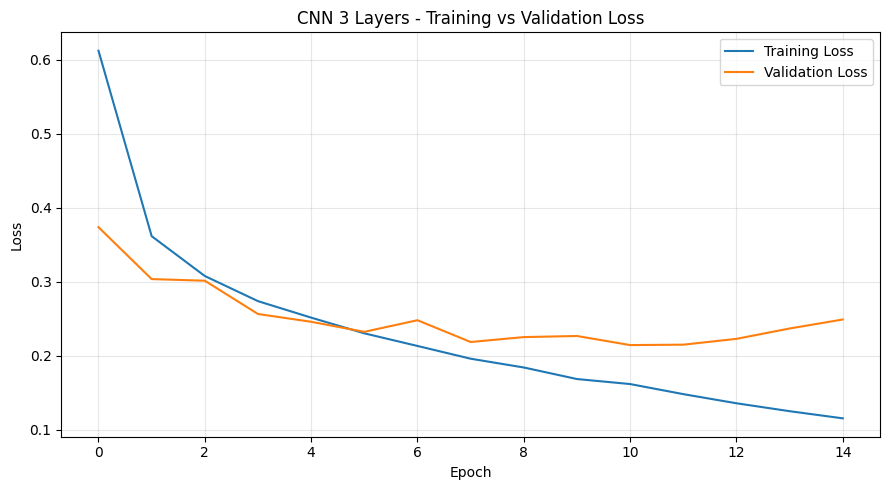

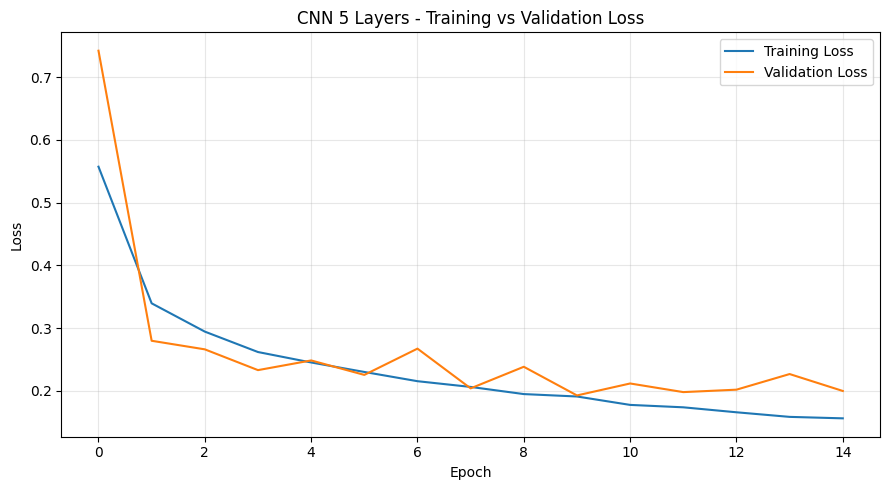

In [33]:
# ============================================================
# TRAINING vs VALIDATION LOSS - ALL 4 MODELS
# ============================================================

for model_name, history in histories.items():

    plt.figure(figsize=(9, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(f"{model_name} - Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

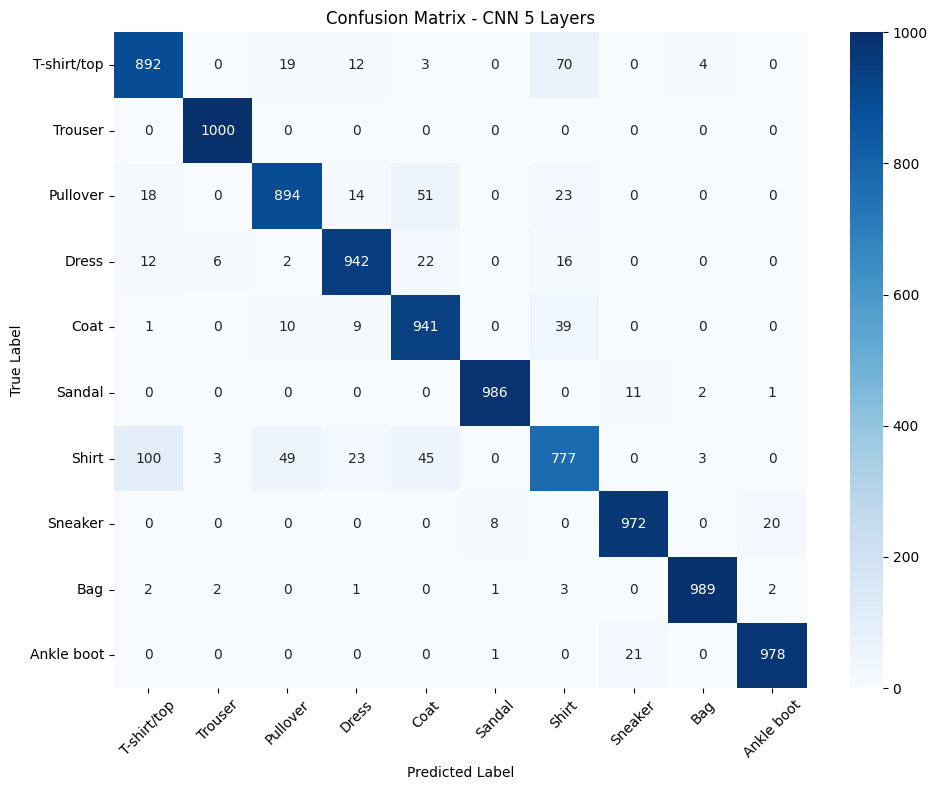

Best Model: CNN 5 Layers
Accuracy: 93.71%


In [34]:
# ============================================================
# CONFUSION MATRIX - BEST MODEL
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

best_model_name = metrics_results.iloc[0]["Model"]

# Select predictions of best model
if best_model_name == "Dense 7 Layers":
    best_predictions = pred_dense7

elif best_model_name == "Dense 10 Layers":
    best_predictions = pred_dense10

elif best_model_name == "CNN 3 Layers":
    best_predictions = pred_cnn3

elif best_model_name == "CNN 5 Layers":
    best_predictions = pred_cnn5

# Create confusion matrix
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {metrics_results.iloc[0]['Accuracy (%)']:.2f}%")

In [35]:
# ============================================================
# CLASSIFICATION REPORT - BEST MODEL
# ============================================================

from sklearn.metrics import classification_report

print("=" * 70)
print(f"CLASSIFICATION REPORT - {best_model_name}")
print("=" * 70)

report = classification_report(
    y_test,
    best_predictions,
    target_names=class_names,
    digits=4
)

print(report)

CLASSIFICATION REPORT - CNN 5 Layers
              precision    recall  f1-score   support

 T-shirt/top     0.8702    0.8920    0.8810      1000
     Trouser     0.9891    1.0000    0.9945      1000
    Pullover     0.9179    0.8940    0.9058      1000
       Dress     0.9411    0.9420    0.9415      1000
        Coat     0.8861    0.9410    0.9127      1000
      Sandal     0.9900    0.9860    0.9880      1000
       Shirt     0.8373    0.7770    0.8060      1000
     Sneaker     0.9681    0.9720    0.9701      1000
         Bag     0.9910    0.9890    0.9900      1000
  Ankle boot     0.9770    0.9780    0.9775      1000

    accuracy                         0.9371     10000
   macro avg     0.9368    0.9371    0.9367     10000
weighted avg     0.9368    0.9371    0.9367     10000



In [ ]:
# ============================================================
# IMAGE PREDICTION FUNCTION
# ============================================================

def predict_image(model, image, model_type):

    image = np.asarray(image)

    if model_type == "dense":
        input_image = image.reshape(1, 784)

    elif model_type == "cnn":
        input_image = image.reshape(1, 28, 28, 1)

    else:
        raise ValueError("model_type must be 'dense' or 'cnn'")

    probabilities = model.predict(
        input_image,
        verbose=0
    )[0]

    predicted_class = np.argmax(probabilities)

    confidence = probabilities[predicted_class] * 100

    return predicted_class, confidence


print("Prediction function created successfully!")

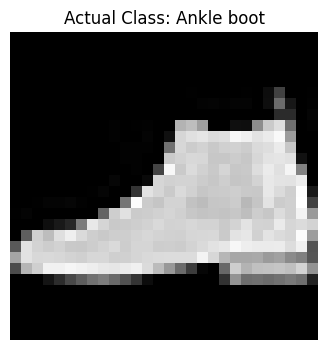

SINGLE IMAGE PREDICTION
Actual Class : Ankle boot

Dense 7  → Trouser         | Confidence: 11.06%
Dense 10 → Ankle boot      | Confidence: 99.93%
CNN 3    → Ankle boot      | Confidence: 100.00%
CNN 5    → Ankle boot      | Confidence: 100.00%


In [38]:
# ============================================================
# SINGLE IMAGE PREDICTION - ALL 4 MODELS
# ============================================================

sample_index = 100

# Get test image
sample_image = X_test[sample_index]
actual_label = y_test[sample_index]

# ------------------------------------------------------------
# DENSE 7 PREDICTION
# ------------------------------------------------------------
prob7 = dense7.predict(
    sample_image.reshape(1, 784),
    verbose=0
)[0]

pred7 = np.argmax(prob7)
conf7 = prob7[pred7] * 100


# ------------------------------------------------------------
# DENSE 10 PREDICTION
# ------------------------------------------------------------
prob10 = dense10.predict(
    sample_image.reshape(1, 784),
    verbose=0
)[0]

pred10 = np.argmax(prob10)
conf10 = prob10[pred10] * 100


# ------------------------------------------------------------
# CNN 3 PREDICTION
# ------------------------------------------------------------
prob3 = cnn3.predict(
    sample_image.reshape(1, 28, 28, 1),
    verbose=0
)[0]

pred3 = np.argmax(prob3)
conf3 = prob3[pred3] * 100


# ------------------------------------------------------------
# CNN 5 PREDICTION
# ------------------------------------------------------------
prob5 = cnn5.predict(
    sample_image.reshape(1, 28, 28, 1),
    verbose=0
)[0]

pred5 = np.argmax(prob5)
conf5 = prob5[pred5] * 100


# ------------------------------------------------------------
# DISPLAY IMAGE
# ------------------------------------------------------------
plt.figure(figsize=(4, 4))

plt.imshow(
    sample_image.reshape(28, 28),
    cmap="gray"
)

plt.title(
    f"Actual Class: {class_names[actual_label]}"
)

plt.axis("off")
plt.show()


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------
print("=" * 70)
print("SINGLE IMAGE PREDICTION")
print("=" * 70)

print(f"Actual Class : {class_names[actual_label]}")
print()

print(
    f"Dense 7  → {class_names[pred7]:15s} | "
    f"Confidence: {conf7:.2f}%"
)

print(
    f"Dense 10 → {class_names[pred10]:15s} | "
    f"Confidence: {conf10:.2f}%"
)

print(
    f"CNN 3    → {class_names[pred3]:15s} | "
    f"Confidence: {conf3:.2f}%"
)

print(
    f"CNN 5    → {class_names[pred5]:15s} | "
    f"Confidence: {conf5:.2f}%"
)

print("=" * 70)

In [39]:
# ============================================================
# SINGLE IMAGE PREDICTION COMPARISON TABLE
# ============================================================

prediction_results = pd.DataFrame({
    "Model": [
        "Dense 7 Layers",
        "Dense 10 Layers",
        "CNN 3 Layers",
        "CNN 5 Layers"
    ],

    "Predicted Class": [
        class_names[pred7],
        class_names[pred10],
        class_names[pred3],
        class_names[pred5]
    ],

    "Confidence (%)": [
        conf7,
        conf10,
        conf3,
        conf5
    ],

    "Correct": [
        pred7 == actual_label,
        pred10 == actual_label,
        pred3 == actual_label,
        pred5 == actual_label
    ]
})

print(f"Actual Class: {class_names[actual_label]}")
print()

display(prediction_results)

Actual Class: Ankle boot



,Model,Predicted Class,Confidence (%),Correct
0,Dense 7 Layers,Trouser,11.061506,False
1,Dense 10 Layers,Ankle boot,99.930801,True
2,CNN 3 Layers,Ankle boot,99.997986,True
3,CNN 5 Layers,Ankle boot,99.999962,True


In [40]:
# ============================================================
# SAVE ALL 4 TRAINED MODELS
# ============================================================

dense7.save("/kaggle/working/dense7_fashion_mnist.keras")
dense10.save("/kaggle/working/dense10_fashion_mnist.keras")
cnn3.save("/kaggle/working/cnn3_fashion_mnist.keras")
cnn5.save("/kaggle/working/cnn5_fashion_mnist.keras")

print("============================================")
print("ALL 4 MODELS SAVED SUCCESSFULLY!")
print("============================================")

print("Dense 7  → dense7_fashion_mnist.keras")
print("Dense 10 → dense10_fashion_mnist.keras")
print("CNN 3    → cnn3_fashion_mnist.keras")
print("CNN 5    → cnn5_fashion_mnist.keras")

ALL 4 MODELS SAVED SUCCESSFULLY!
Dense 7  → dense7_fashion_mnist.keras
Dense 10 → dense10_fashion_mnist.keras
CNN 3    → cnn3_fashion_mnist.keras
CNN 5    → cnn5_fashion_mnist.keras


In [41]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 75)
print("        FASHION-MNIST DEEP LEARNING COMPARISON")
print("=" * 75)

print("\nDataset:")
print("  Training Samples :", X_train.shape[0])
print("  Testing Samples  :", X_test.shape[0])
print("  Input Features   : 784 (28 × 28 pixels)")
print("  Classes           : 10")

print("\nModels Trained:")
print("  1. Dense Neural Network - 7 Layers")
print("  2. Dense Neural Network - 10 Layers")
print("  3. CNN - 3 Convolutional Layers")
print("  4. CNN - 5 Convolutional Layers")

print("\n" + "=" * 75)
print("FINAL MODEL PERFORMANCE")
print("=" * 75)

display(
    metrics_results.style.format({
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1-Score (%)": "{:.2f}"
    })
)

print("\n" + "=" * 75)
print("🏆 BEST MODEL")
print("=" * 75)

best_row = metrics_results.iloc[0]

print(f"Model     : {best_row['Model']}")
print(f"Accuracy  : {best_row['Accuracy (%)']:.2f}%")
print(f"Precision : {best_row['Precision (%)']:.2f}%")
print(f"Recall    : {best_row['Recall (%)']:.2f}%")
print(f"F1-Score  : {best_row['F1-Score (%)']:.2f}%")

print("\n" + "=" * 75)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 75)

        FASHION-MNIST DEEP LEARNING COMPARISON

Dataset:
  Training Samples : 60000
  Testing Samples  : 10000
  Input Features   : 784 (28 × 28 pixels)
  Classes           : 10

Models Trained:
  1. Dense Neural Network - 7 Layers
  2. Dense Neural Network - 10 Layers
  3. CNN - 3 Convolutional Layers
  4. CNN - 5 Convolutional Layers

FINAL MODEL PERFORMANCE


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,CNN 5 Layers,93.71,93.68,93.71,93.67
1,CNN 3 Layers,92.19,92.51,92.19,92.24
2,Dense 10 Layers,88.85,89.38,88.85,88.99
3,Dense 7 Layers,3.54,6.32,3.54,2.20



🏆 BEST MODEL
Model     : CNN 5 Layers
Accuracy  : 93.71%
Precision : 93.68%
Recall    : 93.71%
F1-Score  : 93.67%

PROJECT COMPLETED SUCCESSFULLY!
